# DAI Mission — PROPOSAL
# Pit-Stop Strategy & Race Performance in Formula 1
**Data & AI in Economics | TU Dortmund**

---

> **LLM Disclosure (required by Academic Integrity policy):** This proposal was developed by the project team. AI tools (Claude and/or GitHub Copilot) were used solely for formatting, code checking, debugging assistance, and verification support. All project ideas, analytical decisions, methodology, and proposed analyses are the independent work of the team.



---

## Section 1 — Team

| Role | Name |
|---|---|
| Member | *PATWA, MUNISH* | 
| Member | *BHAVSAR, NIMESH* | 
| Member | *ARORA, SIMRAN* | 

## Section 2 — Mission Title & Research Question

### Title
**Does the Undercut Pay Off? Strategy Archetypes, Outcome Prediction, and the Causal Effect of Pit-Stop Timing in Formula 1 (2022–2025)**

### Overarching Research Question
> **How do pit-stop strategies shape race performance in Formula 1 - and, specifically, does making an early first pit stop (before 40% of the race) *causally* improve a driver's net position gain relative to their grid slot, after accounting for car quality, starting position, and track conditions?**

This umbrella question deliberately houses one shared outcome - **net position gain (`position_vs_start`)** - and is answered through three complementary lenses, one per mandatory method block:

| Sub-question | Lens | Block |
|---|---|---|
| **What** distinct strategy archetypes exist in the field? | descriptive / structure | Unsupervised |
| **How well** can a driver's net position gain be predicted from strategy + race context, and **which factors matter most**? | predictive | Supervised |
| **Does** early pitting *cause* a better net position gain? | causal / inferential | Causal Inference |

The three blocks therefore tell **one coherent story about a single outcome**, rather than three disconnected exercises.

**Specificity check (rubric 1.1):** the causal core names a precise *quantity* (`position_vs_start`), a *population* (dry-race driver-races, 2022–2025), and a *direction* (early pitting *increases* positions gained).

### Economic / Societal Relevance
Pit strategy is the single largest in-race decision lever a team controls, and it is a textbook problem of **decision-making under uncertainty with high stakes**: constructor-championship rank determines prize-money distribution (tens of millions of euros per year) and drives sponsorship value. The deeper econometric hook is **self-selection**: strong cars both pit early *and* finish well, so the raw correlation between early pitting and good results conflates *strategy* with *car quality*. Separating the causal effect of a decision from the confound of who makes it is exactly the problem economists face when evaluating any non-randomly-adopted treatment (job training, subsidies, schooling). Formula 1 is a clean, data-rich sandbox for that methodology - and the predictive and clustering lenses add the practical questions a strategy department actually asks: *what are my options, and what outcome should I expect?*

## Section 3 — Data

### Source & Licensing
| Item | Detail |
|---|---|
| Base data | F1 lap-by-lap timing data, seasons 2022–2025 |
| Enrichment | [OpenF1 API](https://openf1.org) — weather, tyre stints, race control (open data, free for non-commercial use) |
| File | `f1_strategy_v4.csv` - 96,336 rows × 45 columns |
| Provenance | Produced by `clean_f1_dataset.py` → `enrich_with_openf1.py`; documented in `F1_Final_Dataset_Documentation.txt` |

### Unit of Observation
**One row = one lap driven by one driver in one race.** (e.g. Norris, lap 34, British GP 2024.) The data is re-aggregated per block:
- **Supervised & Causal** → one row per **driver per race** (the shared outcome `position_vs_start` is measured at race end).
- **Unsupervised** → one row per **stint** (driver × race × stint).

### Data Availability
A feasibility pass over `f1_strategy_v4.csv` confirms every variable the project needs is present with adequate coverage: first-pit timing (`PitStop`+`RaceProgress`), final position & grid (`Position`, `start_position`, `position_vs_start`), tyre compound & stint (`Compound`, `Stint`, `TyreLife`), degradation (`cumulative_degradation_clean`), team/car tier (`constructor`, `car_performance_tier`), and weather (`track_temp_mean`, `rainfall_any`, 2023–2025). The only material gaps are documented below and handled explicitly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('f1_strategy_v4.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (96336, 45)


,Driver,constructor,car_performance_tier,Race,Year,session_key,LapNumber,laps_to_end,total_race_laps,RaceProgress,...,sc_lap,vsc_lap,red_flag_lap,neutralised_lap,track_temp_mean,track_temp_max,air_temp_mean,humidity_mean,rainfall_any,wind_speed_mean
0,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,1,57,58,0.017241,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
1,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,2,56,58,0.034483,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
2,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,3,55,58,0.051724,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
3,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,4,54,58,0.068966,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872
4,ALB,Williams,back,Abu Dhabi Grand Prix,2023,9197.0,5,53,58,0.086207,...,0,0,0,0,33.460897,38.2,26.962821,51.0,0.0,1.794872


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96336 entries, 0 to 96335
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Driver                        96336 non-null  object 
 1   constructor                   96336 non-null  object 
 2   car_performance_tier          96336 non-null  object 
 3   Race                          96336 non-null  object 
 4   Year                          96336 non-null  int64  
 5   session_key                   76167 non-null  float64
 6   LapNumber                     96336 non-null  int64  
 7   laps_to_end                   96336 non-null  int64  
 8   total_race_laps               96336 non-null  int64  
 9   RaceProgress                  96336 non-null  float64
 10  Compound                      96301 non-null  object 
 11  compound_openf1               96301 non-null  object 
 12  compound_hardness             96336 non-null  int64  
 13  S

In [3]:
df.describe()

,Year,session_key,LapNumber,laps_to_end,total_race_laps,RaceProgress,compound_hardness,Stint,TyreLife,tyre_age_at_start,...,sc_lap,vsc_lap,red_flag_lap,neutralised_lap,track_temp_mean,track_temp_max,air_temp_mean,humidity_mean,rainfall_any,wind_speed_mean
count,96336.000000,76167.000000,96336.000000,96336.000000,96336.000000,96336.000000,96336.000000,96336.000000,96336.000000,96336.000000,...,96336.0,96336.0,96336.000000,96336.000000,96336.000000,96336.000000,96336.000000,96336.000000,96336.000000,96336.000000
mean,2023.600243,9507.978967,30.549556,30.752990,61.302545,0.433581,2.451327,2.055867,14.565189,0.155653,...,0.0,0.0,0.000685,0.054777,35.800047,39.896418,23.882477,52.330118,0.227952,1.975674
std,1.092950,453.005646,18.209573,18.401148,9.035586,0.258689,0.798437,0.953844,10.357856,1.277913,...,0.0,0.0,0.026166,0.227546,8.599187,8.821997,4.674666,15.902343,0.419514,1.033033
min,2022.000000,7779.000000,1.000000,0.000000,28.000000,0.012821,0.000000,1.000000,1.000000,0.000000,...,0.0,0.0,0.000000,0.000000,17.723776,19.400000,14.430000,18.233766,0.000000,0.683230
25%,2023.000000,9189.000000,15.000000,15.000000,53.000000,0.211268,2.000000,1.000000,7.000000,0.000000,...,0.0,0.0,0.000000,0.000000,30.000000,34.000000,20.077358,42.000000,0.000000,1.249677
50%,2024.000000,9574.000000,30.000000,30.000000,58.000000,0.421053,3.000000,2.000000,13.000000,0.000000,...,0.0,0.0,0.000000,0.000000,35.602516,38.800000,24.036527,52.518750,0.000000,1.667832
75%,2025.000000,9888.000000,45.000000,45.000000,70.000000,0.633803,3.000000,3.000000,20.000000,0.000000,...,0.0,0.0,0.000000,0.000000,42.928205,47.000000,27.431677,63.901235,0.000000,2.188312
max,2025.000000,10033.000000,78.000000,77.000000,78.000000,1.000000,5.000000,8.000000,78.000000,53.000000,...,0.0,0.0,1.000000,1.000000,52.000000,58.000000,34.000000,85.258706,1.000000,6.000000


### Variable Table (key variables, by role)

| Variable | Type | Role | Description |
|---|---|---|---|
| `Driver`, `Race`, `Year` | string/int | identifier | grouping keys (always pair Race+Year) |
| `car_performance_tier` | ordinal | **confounder / feature** | top / mid / back — car quality that season |
| `start_position` | float | **confounder / feature** | grid position; drives both strategy and outcome |
| `track_temp_mean` | float | **confounder / feature** | race track temperature; hotter → faster tyre wear |
| `rainfall_any` | binary | **confounder / feature** | did it rain? fundamentally changes strategy |
| `first_pit_progress` *(derived)* | float | **treatment driver** | race-progress of the first pit → defines `early_pit` |
| `Compound`, `compound_hardness` | nominal/ordinal | feature | tyre compound / hardness |
| `TyreLife`, `Stint` | float/int | feature | tyre age, stint number |
| `cumulative_degradation_clean` | float | feature / mechanism | seconds slower than stint baseline (NaN on slow laps — intentional) |
| `RaceProgress`, `laps_to_end` | float/int | feature | race-timing variables |
| `position_vs_start` | float | **★ shared outcome ★** | positions gained (+) / lost (-) vs grid — **supervised target AND causal outcome** |
| `PitNextLap` | binary | secondary target | used only in the mechanism check (pit-decision model) |
| `is_slow_lap`, `is_wet_lap`, `red_flag_lap` | binary | filter flags | exclude from degradation / dry-strategy analysis |
| `sc_lap`, `vsc_lap`, `neutralised_lap` | binary | **unusable** | corrupted (all-zero join bug) — *not* used as feature or instrument |

### Known Data Quality Concerns & Handling (rubric 1.4)

| Issue | Impact | Handling decision |
|---|---|---|
| `track_temp_mean` & all OpenF1 cols null for **all of 2022** (API starts 2023) | 20.9% of rows | Causal block uses 2023–2024; predictive trees handle weather NaN natively |
| `cumulative_degradation_clean` NaN on slow laps (8.3%) | **Intentional**, not random | Do not impute; `dropna()` or use tree models |
| `sc_lap` / `vsc_lap` all-zero (API join bug) | Safety-car variable unusable | **Not** used as feature; **not** used as IV (see §4 Block A) |
| `pit_duration` 99.9% null | unusable | descriptive only, dropped |
| 1,061 `constructor='Unknown'` rows (mid-season subs) | coarse tier missing | drop |
| `Normalized_TyreLife`, `LapTime_Delta`, `Cumulative_Degradation` | deprecated/corrupted | excluded entirely |

In [ ]:
# Null Counts and Percentages for Key Columns
key_cols = ['LapTime (s)','Position','TyreLife','cumulative_degradation_clean',
            'track_temp_mean','rainfall_any','car_performance_tier','Compound',
            'position_vs_start','PitNextLap','start_position']
pd.DataFrame({'null_count': df[key_cols].isnull().sum(),
              'null_pct': (df[key_cols].isnull().mean()*100).round(1)})

,null_count,null_pct
LapTime (s),0,0.0
Position,0,0.0
TyreLife,0,0.0
cumulative_degradation_clean,8835,9.2
track_temp_mean,0,0.0
rainfall_any,0,0.0
car_performance_tier,0,0.0
Compound,35,0.0
position_vs_start,0,0.0
PitNextLap,0,0.0


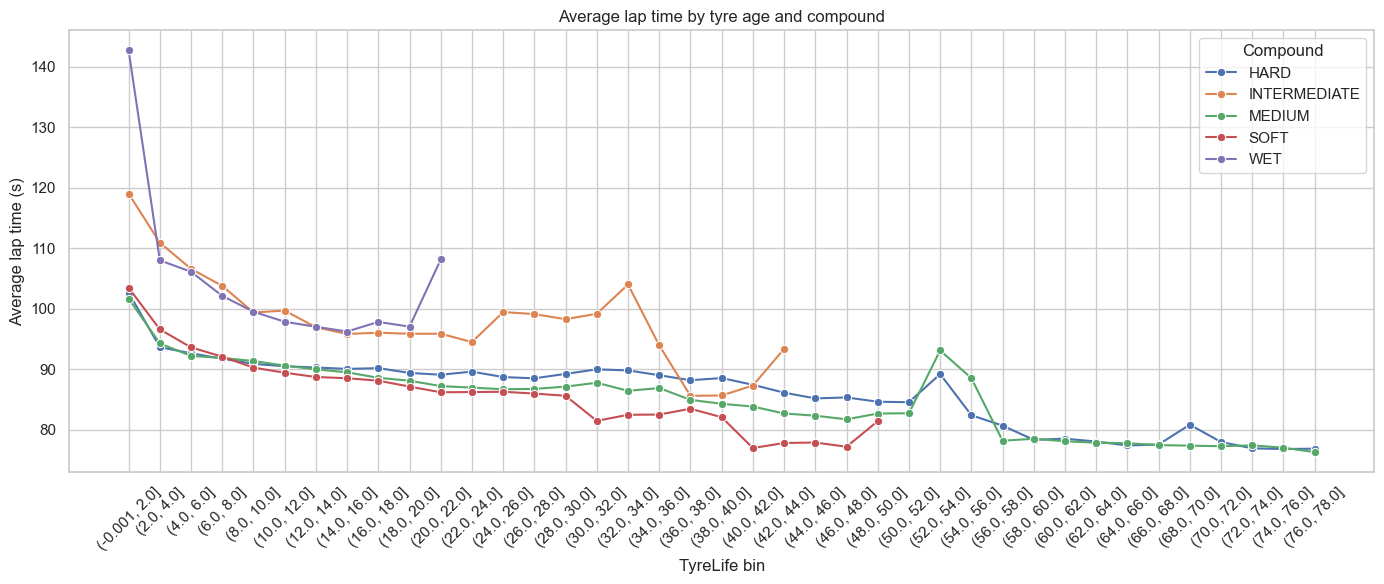

In [6]:
# Lap time trend with tyre age
trend_df = (
    df.dropna(subset=['TyreLife', 'LapTime (s)', 'Compound'])
      .assign(TyreLifeBin=lambda x: pd.cut(x['TyreLife'], bins=np.arange(0, x['TyreLife'].max() + 2, 2), include_lowest=True))
      .groupby(['Compound', 'TyreLifeBin'], observed=True, as_index=False)['LapTime (s)']
      .mean()
)
trend_df['TyreLifeBin_str'] = trend_df['TyreLifeBin'].astype(str)
trend_df = trend_df.sort_values(['Compound', 'TyreLifeBin'])
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=trend_df, x='TyreLifeBin_str', y='LapTime (s)', hue='Compound', marker='o', ax=ax)
ax.set_title('Average lap time by tyre age and compound')
ax.set_xlabel('TyreLife bin')
ax.set_ylabel('Average lap time (s)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Section 4 — Planned Methods

*One technique from each mandatory block. All three revolve around the **same outcome**, `position_vs_start`, so each result informs the next.*

### Block C — Unsupervised: K-Means clustering of stints
**Task:** discover the distinct tyre-strategy **archetypes** in the field, with no labels.  
**Unit:** one stint (driver × race × stint), dry compounds only.  
**Why K-Means:** we expect a small number (≈3–4) of interpretable types (aggressive short-soft, standard medium, conservative long-hard); K-Means yields **centroid-interpretable** clusters we can label in domain terms. *k* is selected by the **elbow** (inertia) and **silhouette** score; hierarchical clustering is used as a cross-check.  
**Feeds forward:** the cluster labels become a *strategy-type feature* for the supervised model, and the clusters' first-pit-lap distributions give a **data-driven justification** for the early-pit treatment threshold used in the causal block (instead of an arbitrary 40%).

### Block B — Supervised : predict net position gain (`position_vs_start`)
**Task:** a **regression** predicting a driver's end-of-race `position_vs_start` from grid slot, car tier, tyre strategy (compounds, number of stops, first-pit timing, strategy cluster), and track conditions.  
**Why this target (not the pit decision):** it is the *same* outcome as the causal block and the *direct* subject of the research question, so the predictive and causal lenses examine one quantity from two angles — **prediction** (minimise out-of-sample error using *all* signal) vs **inference** (isolate one treatment's effect with careful confounder control). That prediction-vs-inference contrast is itself a key synthesis point.  
**Models (justified by the task):** race outcomes are **non-linear** and full of **interactions** (e.g. a soft-tyre gamble only pays off on a cool track), so we compare a **Linear/Ridge Regression baseline** against **Random Forest** and **HistGradient Boosting** (a gradient-boosting method in the XGBoost family; built into scikit-learn and handles the intentional NaNs natively). A naive baseline (predict the mean, and a grid-position-only model) sets the floor.  
**Mechanism check (secondary):** we additionally fit a small classifier for `PitNextLap` *purely to confirm the DAG's mechanism* — that tyre degradation and laps-remaining drive pit timing — and we run a **feature-leakage audit** there (in-lap features can leak the pit decision). This is reported as supporting evidence, not the headline.

### Block A — Causal Inference: Backdoor adjustment (DAG) via DoWhy
**Treatment:** `early_pit` (first pit before the data-driven threshold ≈ 40%). **Outcome:** `position_vs_start`.  
**The core problem = confounding:** fast cars pit early *and* finish well, so we must hold car quality fixed. We encode the assumptions as a **DAG** and identify the effect by **backdoor adjustment** on the observed confounders `{car_performance_tier, start_position, track_temp_mean, rainfall_any}`.  
**Estimation:** DoWhy with **linear-regression** adjustment as the primary estimator, plus **propensity-score** methods (weighting and matching) as robustness — the estimates must broadly agree.  

**Why NOT an instrumental variable (important rigor point):** the natural instrument would be **Safety-Car (SC) deployment** (a crash elsewhere is quasi-random and forces a cheap pit). We **explored but rejected** it for two reasons:
1. **Practical:** the `sc_lap`/`vsc_lap` fields are corrupted (all-zero) from an API join bug, so no usable instrument exists in the data.
2. **Conceptual (the decisive one):** even with clean data, an SC would almost certainly **violate the exclusion restriction**. A valid instrument must affect the outcome *only* through the treatment, but an SC influences final positions through *many* channels — it bunches the field, neutralises time gaps, enables restart overtakes, and simultaneously changes *every rival's* strategy — not solely through the focal driver's pit timing.

Backdoor adjustment on observed confounders is therefore the more defensible identification strategy here, and we say so explicitly rather than claiming a clean IV.

**Extension (foreshadowed):** beyond the binary early/late treatment we will sweep first-pit *timing* across windows and estimate each window's confounder-adjusted position gain, to locate the value-maximising pit window (an inverted-U / undercut-window hypothesis). This becomes Section 7.4 in the final.

## Section 5 — Evaluation Strategy

| Block | Primary metric | Baseline / validation | Why |
|---|---|---|---|
| **Unsupervised** | **Silhouette score** (+ elbow/inertia) | compare k = 2…8; accept silhouette > 0.3 | quantifies cluster separation without ground-truth labels |
| **Supervised** | **RMSE** (primary), MAE, R² | (a) predict-the-mean and (b) grid-position-only baselines; Linear/Ridge vs RF vs HistGradient Boosting; **TimeSeriesSplit** CV | RMSE is the natural error metric for a continuous outcome (positions); baselines show whether strategy features add real signal beyond the grid |
| **Causal** | **ATE** (positions) with 95% CI | two estimators (linear regression + propensity-score weighting/matching) must agree; **3 refutation tests** | a causal number is credible only if robust to estimator choice and surviving refutation |

**Refutation tests (causal):** (1) *random common cause* — adding a random confounder should barely move the estimate; (2) *placebo treatment* — shuffling the treatment should collapse the effect toward 0; (3) *data subset* — re-estimating on 80% subsamples should stay stable.

**Train/test protocol (supervised) — TEMPORAL, not random.** Train on the earlier seasons and test on the most recent held-out season (e.g. train 2022–2024, test 2025). A random split would place laps from the same race (and future seasons) in both train and test, leaking information forward; cars and regulations also change year-to-year, so a temporal holdout is the only honest test of generalisation.

**Note on the outcome's noise:** `position_vs_start` is genuinely noisy at race level (DNFs, crashes, penalties cause large swings), so a modest R² is expected and will be reported honestly — the informative question is whether strategy features beat the grid-only baseline, not whether R² is high.

_Other Evaluation Strategies could be added during final submission_

## Section 6 — Work Plan

| Step | Owner | Task | Output |
|---|---|---|---|
| 1 | Munish |**Data cleaning** — drop wet/red-flag/unknown-tier rows; encode tier; build `true_tyre_age`; derive `first_pit_progress` | clean lap- & race-level frames |
| 2 | Nimesh |**Exploratory analysis** — degradation curves, pit-timing histogram, outcome by car tier | EDA figures |
| 3 | Simran |**Unsupervised block** — stint aggregation, k-selection, cluster labelling → strategy-type feature | clusters + silhouette |
| 4 | Munish|**Supervised block** — predict `position_vs_start`: baselines vs RF vs HistGradient Boosting; temporal CV; feature importance; (+ pit-decision mechanism check with leakage audit) | RMSE/R² table + importances |
| 5 | Nimesh |**Causal block** — DAG (threshold informed by clusters), backdoor estimation, propensity-score robustness, refutation | ATE + refutation table |
| 6 | Simran |**Optimal pit-window analysis** (extension) — confounder-adjusted position gain per first-pit window | inverted-U curve + optimal window |
| 7 | Munish |**Synthesis** — connect the blocks around the shared outcome, answer the RQ, limitations | discussion |

**The synthesis spine:** *cluster the strategies → predict the outcome they produce → causally test whether early pitting drives that outcome → locate the optimal window.* One outcome, three methods, each informing the next.

---
*End of proposal. Sections 7–8 (Results & Discussion) will be completed for the final submission after this proposal is approved.*